# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [60]:
# Import the library
import cv2
import numpy as np
from PIL import Image, ImageOps
from skimage import data
import matplotlib.pyplot as plt


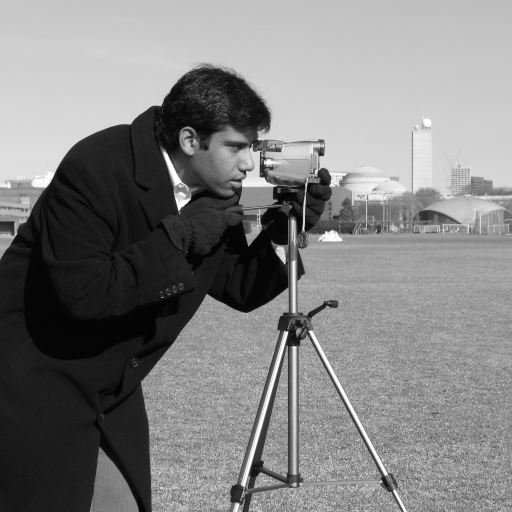

In [9]:
# ── Load image ────────────────────────────────────
img= Image.fromarray(data.camera())
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [23]:
# Get the size of the image
print(img.size)
# scaling factors
cx=2
cy=2

new_size = (img.width * cx, img.height * cy)
print(new_size)

(512, 512)
(1024, 1024)


In [24]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

new_size= (img.width*2 , img.height*2)
imgres= img.resize(new_size, Image.Resampling.LANCZOS)

print(imgres.size)


(1024, 1024)


In [25]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
imgres.save("task1_1_scaled.jpg")

print("Og size: ", img.size)
print("rescaled size: ", imgres.size)

Og size:  (512, 512)
rescaled size:  (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [34]:
# Scaling factors horizontally
cx= 2
cy=1 

new_size= (img.width * cx, img.height * cy)
print(new_size)

(1024, 512)


In [31]:
imgres1= img.resize(new_size, Image.Resampling.LANCZOS)
print(imgres1.size)

(1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [35]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
imgres2.save("task1_2_rotated.jpg")

print("og size 2: " , img.size)
print("rescaled size 2: ", imgres.size)

og size 2:  (512, 512)
rescaled size 2:  (1024, 512)


### 3. Shear

In [37]:
# -- c. Get the image dimensions ────────────────────
print(img.size)

(512, 512)


In [38]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shearFactor= 0.5 # will be for X-axis

shearMtrx= np.array([
    [1, shearFactor],
    [0, 1]
])

print(shearMtrx)

[[1.  0.5]
 [0.  1. ]]


In [42]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

shx = 0.5
shy = 0

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


In [44]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
shear_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

### Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

In [45]:
shearFactor= 0.1

shearMtrx= np.array([
    [1, shearFactor],
    [0, 1]
])

print(shearMtrx)

[[1.  0.1]
 [0.  1. ]]


In [46]:
shx = 0.1
shy = 0

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


In [47]:
shearFactor= 0.3

shearMtrx= np.array([
    [1, shearFactor],
    [0, 1]
])

print(shearMtrx)

[[1.  0.3]
 [0.  1. ]]


In [48]:
shx = 0.3
shy = 0

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


In [49]:
shearFactor= 0.8

shearMtrx= np.array([
    [1, shearFactor],
    [0, 1]
])

print(shearMtrx)

[[1.  0.8]
 [0.  1. ]]


In [50]:
shx = 0.8
shy = 0

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


Whenever changing the shear factor  for same X-axis the dimensions will not be affected, It is all about the changine the shape of image

### Switch from X-axis to Y-axis shear matrix

In [51]:
shearFactor= 0.5 

shearMtrx= np.array([
    [1, 0],
    [shearFactor, 1]
])

print(shearMtrx)

[[1.  0. ]
 [0.5 1. ]]


In [52]:
shx = 0 #no horizontal shear
shy = 0.5

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


### Update the canvas multiplier to match your new factor

In [53]:
canvas_multiplier = 1 + abs(shy)

new_size = (
    int(img.width * canvas_multiplier),
    int(img.height * canvas_multiplier)
)

print(new_size)

(768, 768)


### Try combining X and Y shear in one matrix

In [54]:
shearFactorX= 0.5
shearFactorY= 0.5

shMtrx= np.array([
    [1, shearFactorX],
    [shearFactorY, 1]
])

print(shMtrx)

[[1.  0.5]
 [0.5 1. ]]


img will get slanted in both horizontal and vertical directions

In [55]:
shx = 0.5
shy = 0.5

shear_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    (1, shx, 0, shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print(shear_img.size)

(512, 512)


# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [58]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
imgarr= np.array(img)

negarr = 255 - imgarr

negimg = Image.fromarray(negarr.astype(np.uint8))

print(negimg.size)

(512, 512)


In [61]:
# Method 2: PIL's ImageOps
negimg_pil = ImageOps.invert(img.convert("RGB"))

print(negimg_pil.size)


(512, 512)


In [64]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c= 255 / np.log(1 + 255)

imgarr= np.array(img).astype(np.float32)

# Apply the log transformation to each pixel

log_transform= c * np.log(1 + imgarr)

log_transform= np.uint8(log_transform)

log_transform_img= Image.fromarray(log_transform)

print(log_transform_img.size)

(512, 512)


In [65]:
# ── 3. Power-law / Gamma correction ───────────────
gamma= 2.2

imgarr= np.array(img).astype(np.float32) / 255.0

# Apply gamma correction
gamma_transformed_arr= 255 * (imgarr ** gamma)

gamma_transformed_arr= np.uint8(gamma_transformed_arr)

gimg= Image.fromarray(gamma_transformed_arr)

print(gimg.size)

(512, 512)
